# Sigmoid Activation Function

The **Sigmoid function**, also known as the logistic function, is a widely used activation function in binary classification and neural networks. It maps any real-valued input into a range between **0 and 1**.

---

### 1. Mathematical Definition
As implemented in the `__call__` method, the Sigmoid function $\sigma(x)$ is defined as:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

#### Characteristics:
* **Range:** $(0, 1)$.
* **S-Shape:** It produces a characteristic "S" curve.

[Image of the Sigmoid function graph]

* **Interpretation:** Because its output is between 0 and 1, it is often interpreted as a probability.

---

### 2. Gradient Derivation
The `gradient` method implements the derivative of the Sigmoid function, which is essential for backpropagation. A unique property of Sigmoid is that its derivative can be expressed in terms of its own output.

#### Step-by-Step Derivation:
Given $\sigma(x) = (1 + e^{-x})^{-1}$, we apply the **Chain Rule**:

1.  **Power Rule:** $$\frac{d}{dx} \sigma(x) = -1 \cdot (1 + e^{-x})^{-2} \cdot \frac{d}{dx}(1 + e^{-x})$$
2.  **Inner Derivative:** The derivative of $(1 + e^{-x})$ is $-e^{-x}$.
    $$\frac{d}{dx} \sigma(x) = \frac{e^{-x}}{(1 + e^{-x})^2}$$
3.  **Algebraic Trick:** We rewrite the numerator as $(1 + e^{-x}) - 1$:
    $$\frac{d}{dx} \sigma(x) = \frac{(1 + e^{-x}) - 1}{(1 + e^{-x})^2} = \frac{1}{1 + e^{-x}} - \frac{1}{(1 + e^{-x})^2}$$
4.  **Final Form:**
    $$\frac{d}{dx} \sigma(x) = \sigma(x) \cdot (1 - \sigma(x))$$

---

In [1]:
class Sigmoid():
    def __call__(self, x):
        return 1 / (1 + np.exp(-x))

    def gradient(self, x):
        return self.__call__(x) * (1 - self.__call__(x))

# Softmax Activation Function

The **Softmax function** is the standard activation function for the output layer of a multi-class classification neural network. It turns a vector of raw scores (logits) into a **probability distribution** where each value is between 0 and 1, and the total sum of all values is exactly 1.

---

### 1. Mathematical Definition
For an input vector $x$ with $n$ elements, the Softmax of the $i$-th element is defined as:

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}$$

#### Key Properties:
* **Probability Mapping:** Every output is in the range $(0, 1)$.
* **Sum to One:** $\sum \text{Softmax}(x) = 1$.
* **Relative Magnitudes:** It amplifies the largest values while suppressing those significantly smaller than the maximum.



---

### 2. Numerical Stability (The "Max Trick")
Your code includes a common optimization: `x - np.max(x)`.

```python
e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))

In [3]:
import numpy as np

class Softmax():
    def __call__(self, x):
        e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return e_x / np.sum(e_x, axis=-1, keepdims=True)

    def gradient(self, x):
        p = self.__call__(x)
        return p * (1 - p)

# Hyperbolic Tangent (TanH) Activation Function

The **TanH function** is an activation function that maps any real-valued input into a range between **-1 and 1**. It is often preferred over the Sigmoid function for hidden layers because its output is **zero-centered**, which helps speed up the convergence of backpropagation.

---

### 1. Mathematical Definition
As implemented in your `__call__` method, TanH is defined as a rescaled and shifted version of the Sigmoid function:

$$\text{TanH}(x) = \frac{2}{1 + e^{-2x}} - 1$$

#### Characteristics:
* **Range:** $(-1, 1)$.

[Image of TanH function graph]

* **Zero-Centered:** Unlike Sigmoid (range 0 to 1), TanH outputs average to zero, which helps prevent "zig-zagging" updates during gradient descent.
* **Relationship to Sigmoid:** $\text{TanH}(x) = 2\sigma(2x) - 1$.

---

### 2. Gradient Derivation
The `gradient` method implements the derivative of TanH, which can be elegantly expressed in terms of its own output.

#### Step-by-Step Derivation:
Standard calculus defines $\frac{d}{dx}\tanh(x) = \text{sech}^2(x)$. Using the trigonometric identity $1 - \tanh^2(x) = \text{sech}^2(x)$, we get:

$$\frac{d}{dx}\text{TanH}(x) = 1 - \text{TanH}(x)^2$$

In your code, this is calculated as:
```python
return 1 - np.power(self.__call__(x), 2)

In [4]:
class TanH():
    def __call__(self, x):
        return 2 / (1 + np.exp(-2*x)) - 1

    def gradient(self, x):
        return 1 - np.power(self.__call__(x), 2)

# ReLU (Rectified Linear Unit) Activation Function

**ReLU** is currently the most widely used activation function for hidden layers in deep learning models. It is computationally efficient and helps mitigate the **vanishing gradient problem** that affects functions like Sigmoid and TanH.

---

### 1. Mathematical Definition
As implemented in your `__call__` method, ReLU is a piecewise linear function that outputs the input directly if it is positive, and zero otherwise:

$$f(x) = \max(0, x)$$

#### Characteristics:
* **Range:** $[0, \infty)$.
* **Sparsity:** It outputs exactly zero for all negative inputs, which means only a subset of neurons are "active" at any given time.
* **Linearly Unbounded:** Unlike Sigmoid or TanH, it does not saturate in the positive direction.



---

### 2. Gradient Calculation
The `gradient` method implements the derivative of ReLU. Because the function is piecewise, its derivative is a step function:

$$f'(x) = \begin{cases} 1 & \text{if } x \geq 0 \\ 0 & \text{if } x < 0 \end{cases}$$

#### Why this is important:
* **Constant Gradient:** For any positive input, the gradient is a constant **1**. This ensures that gradients do not "shrink" or vanish as they are multiplied during backpropagation through many layers.
* **Efficiency:** The derivative requires no complex math (like exponentials)—it is a simple conditional check.

---

### 3. Pros and Cons

| Feature | Description |
| :--- | :--- |
| **Computational Speed** | Extremely fast to compute compared to Sigmoid or TanH. |
| **Vanishing Gradient** | Effectively prevents gradients from vanishing in the positive region. |
| **"Dying ReLU" Problem** | If a neuron gets stuck in the negative region ($x < 0$), its gradient becomes 0, and it may never "wake up" or update again. |

---

In [6]:
class ReLU():
    def __call__(self, x):
        return np.where(x >= 0, x, 0)

    def gradient(self, x):
        return np.where(x >= 0, 1, 0)

# Leaky ReLU Activation Function

**Leaky ReLU** is a variant of the Rectified Linear Unit (ReLU) designed to address the **"Dying ReLU"** problem. In a standard ReLU, neurons that output negative values have a gradient of zero, which can cause them to become "dead" and stop updating entirely.

---

### 1. Mathematical Definition
As implemented in the `__call__` method, Leaky ReLU introduces a small slope ($\alpha$) for negative inputs instead of flatlining at zero:

$$f(x) = \begin{cases} x & \text{if } x \geq 0 \\ \alpha x & \text{if } x < 0 \end{cases}$$



#### Key Characteristics:
* **Hyperparameter ($\alpha$):** A small constant (defaulting to **0.2** in your code) that determines the "leak".
* **Range:** $(-\infty, \infty)$.
* **Non-Zero Gradient:** Unlike standard ReLU, it provides a small, non-zero gradient for negative values, allowing the neuron to continue learning.

---

### 2. Gradient Calculation
The `gradient` method implements the derivative of Leaky ReLU. It is a piecewise constant function:

$$f'(x) = \begin{cases} 1 & \text{if } x \geq 0 \\ \alpha & \text{if } x < 0 \end{cases}$$

#### Why this is a fix:
By ensuring the gradient is never exactly zero (it is $\alpha$ for $x < 0$), the optimizer can always push the weight back toward the positive region if necessary. This keeps the neuron "alive" throughout training.

---

In [7]:
class LeakyReLU():
    def __init__(self, alpha=0.2):
        self.alpha = alpha

    def __call__(self, x):
        return np.where(x >= 0, x, self.alpha * x)

    def gradient(self, x):
        return np.where(x >= 0, 1, self.alpha)

# ELU (Exponential Linear Unit) Activation Function

**ELU** is an activation function that tends to converge cost to zero faster and produce more accurate results. Like Leaky ReLU, it addresses the "Dying ReLU" problem by having a non-zero gradient for negative inputs, but it uses an **exponential curve** instead of a straight line to ensure a smoother transition.

---

### 1. Mathematical Definition
As implemented in the `__call__` method, ELU is defined as:

$$f(x) = \begin{cases} x & \text{if } x \geq 0 \\ \alpha(e^x - 1) & \text{if } x < 0 \end{cases}$$



#### Key Characteristics:
* **Alpha ($\alpha$):** A hyperparameter (defaulting to **0.1** in your code) that controls the value to which an ELU saturates for high negative net inputs.
* **Smoothness:** Unlike ReLU and Leaky ReLU, ELU is smooth ($C^1$ continuous) at $x=0$ if $\alpha=1$, which can help optimization.
* **Mean Activation:** By having negative values, ELU pushes the mean unit activations closer to zero, which speeds up learning (similar to Batch Normalization).

---

### 2. Gradient Calculation
The `gradient` method implements the derivative of the ELU function.

For $x < 0$, the derivative is:
$$\frac{d}{dx} [\alpha(e^x - 1)] = \alpha e^x$$

**Optimization Trick:**
Since $f(x) = \alpha e^x - \alpha$ for $x < 0$, we can rewrite $\alpha e^x$ as $f(x) + \alpha$. This allows the gradient to be calculated using the output of the forward pass:

$$f'(x) = \begin{cases} 1 & \text{if } x \geq 0 \\ f(x) + \alpha & \text{if } x < 0 \end{cases}$$

---

In [8]:
class ELU():
    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def __call__(self, x):
        return np.where(x >= 0.0, x, self.alpha * (np.exp(x) - 1))

    def gradient(self, x):
        return np.where(x >= 0.0, 1, self.__call__(x) + self.alpha)

# SELU (Scaled Exponential Linear Unit) Activation Function

**SELU** is a specialized activation function that allows for the creation of **Self-Normalizing Neural Networks (SNNs)**. When using SELU, the activations of each layer will automatically converge toward a mean of zero and unit variance, which eliminates the need for external techniques like Batch Normalization in deep architectures.

---

### 1. Mathematical Definition
As implemented in the `__call__` method, SELU is a scaled version of the ELU function using two very specific predefined constants:

$$f(x) = \lambda \begin{cases} x & \text{if } x \geq 0 \\ \alpha(e^x - 1) & \text{if } x < 0 \end{cases}$$



#### The Magic Constants:
To achieve the self-normalizing property, these exact values must be used:
* **Scale ($\lambda$):** $\approx 1.0507$
* **Alpha ($\alpha$):** $\approx 1.6733$

#### Characteristics:
* **Internal Normalization:** It preserves the mean and variance of the inputs across many layers.
* **Vanishing/Exploding Gradient:** It is highly robust against these problems because the internal normalization keeps gradients in a healthy range.
* **Requirements:** For self-normalization to work, weights should be initialized with **LeCun Normal Initialization**.

---

### 2. Gradient Calculation
The `gradient` method implements the derivative of the SELU function, incorporating the `scale` factor:

$$f'(x) = \lambda \begin{cases} 1 & \text{if } x \geq 0 \\ \alpha e^x & \text{if } x < 0 \end{cases}$$

Your implementation correctly applies the `scale` to both the positive and negative branches of the derivative.

---

In [9]:
class SELU():
    def __init__(self):
        self.alpha = 1.6732632423543772848170429916717
        self.scale = 1.0507009873554804934193349852946

    def __call__(self, x):
        return self.scale * np.where(x >= 0.0, x, self.alpha*(np.exp(x)-1))

    def gradient(self, x):
        return self.scale * np.where(x >= 0.0, 1, self.alpha * np.exp(x))

# SoftPlus Activation Function

**SoftPlus** is a smooth, continuous alternative to the ReLU activation function. While ReLU has a "sharp" corner at zero, SoftPlus provides a gradual transition, making it differentiable at all points.

---

### 1. Mathematical Definition
As implemented in the `__call__` method, the SoftPlus function is defined as:

$$f(x) = \ln(1 + e^x)$$

#### Characteristics:
* **Range:** $(0, \infty)$.
* **Smoothness:** It is a smooth function that avoids the abrupt change in gradient found in ReLU at $x=0$.
* **Relationship to ReLU:** As $x$ becomes very large, SoftPlus behaves almost linearly, similar to ReLU ($f(x) \approx x$).

---

### 2. Gradient Derivation
The `gradient` method implements the derivative of SoftPlus, which results in a familiar function: the **Sigmoid** function.

#### Step-by-Step Derivation:
Given $f(x) = \ln(1 + e^x)$, we apply the **Chain Rule**:

1.  **Outer Derivative:** The derivative of $\ln(u)$ is $\frac{1}{u}$.
    $$\frac{d}{dx} \ln(1 + e^x) = \frac{1}{1 + e^x} \cdot \frac{d}{dx}(1 + e^x)$$
2.  **Inner Derivative:** The derivative of $(1 + e^x)$ is $e^x$.
    $$\frac{d}{dx} f(x) = \frac{e^x}{1 + e^x}$$
3.  **Simplification:** Divide the numerator and denominator by $e^x$:
    $$\frac{d}{dx} f(x) = \frac{1}{\frac{1}{e^x} + 1} = \frac{1}{1 + e^{-x}}$$

**Result:** The derivative of SoftPlus is exactly the **Sigmoid function** $\sigma(x)$.

---

In [10]:
class SoftPlus():
    def __call__(self, x):
        return np.log(1 + np.exp(x))

    def gradient(self, x):
        return 1 / (1 + np.exp(-x))

# Comparative Analysis of Activation Functions

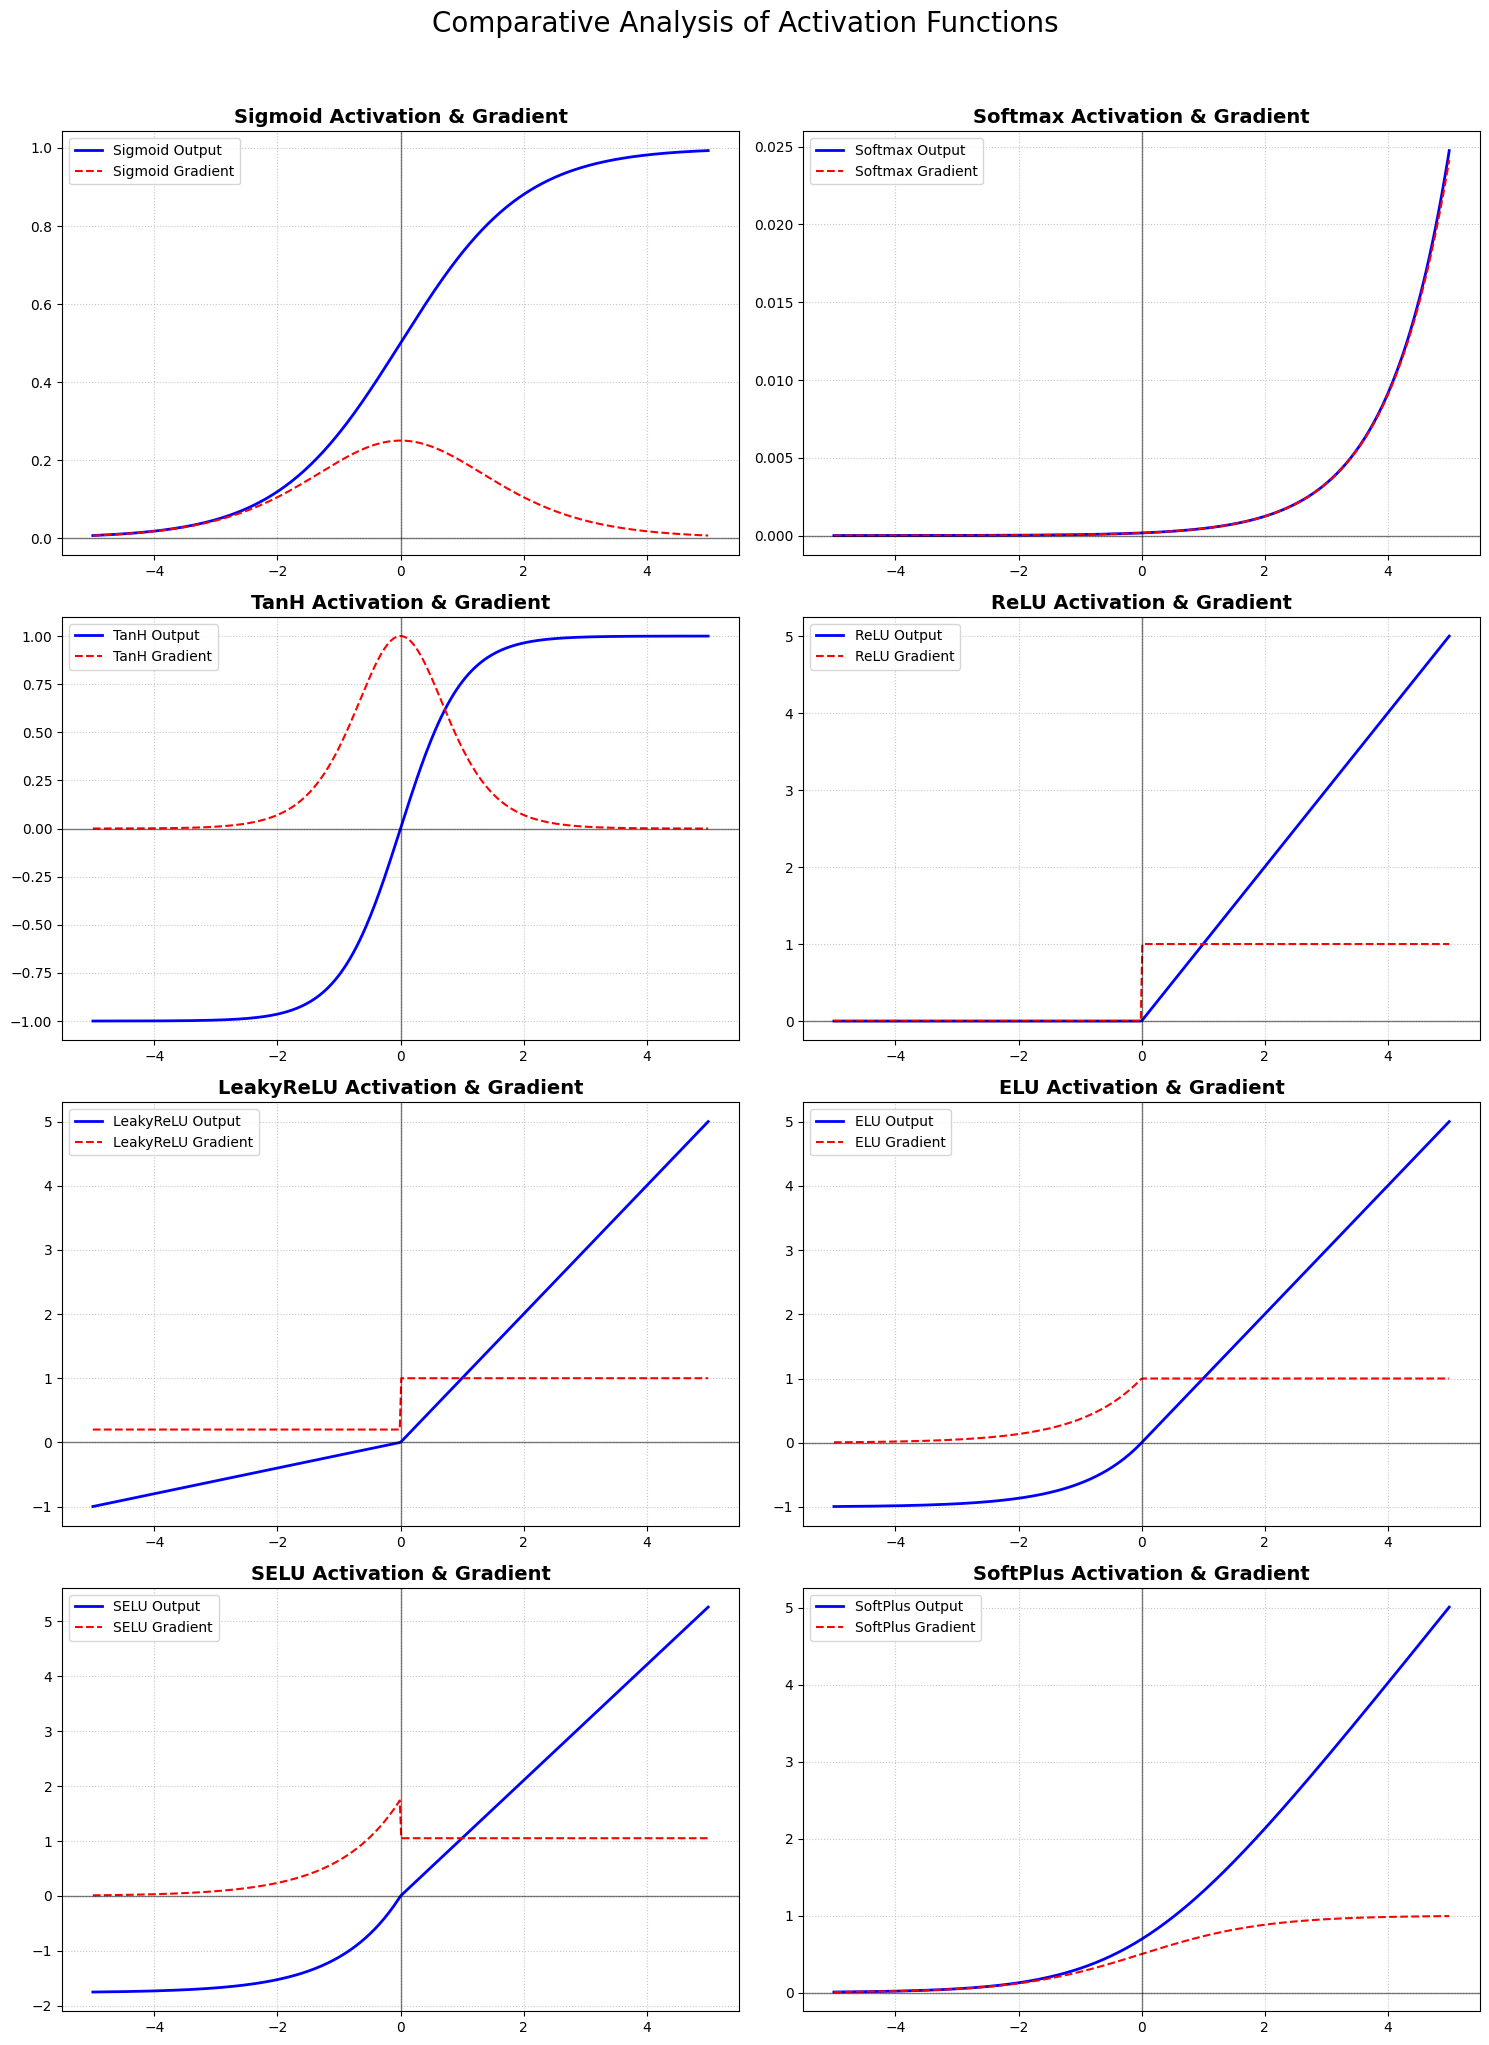

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def test_activation_functions():
    # 1. Initialize all activation function classes
    activations = {
        "Sigmoid": Sigmoid(),
        "Softmax": Softmax(),
        "TanH": TanH(),
        "ReLU": ReLU(),
        "LeakyReLU": LeakyReLU(alpha=0.2),
        "ELU": ELU(alpha=1.0),
        "SELU": SELU(),
        "SoftPlus": SoftPlus()
    }

    # 2. Create sample data (from -5 to 5)
    x = np.linspace(-5, 5, 400)

    # 3. Setup Plotting
    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    axes = axes.flatten()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, (name, func) in enumerate(activations.items()):
        # Forward pass
        y = func(x)
        # Gradient pass
        dy = func.gradient(x)

        # Plotting
        ax = axes[i]
        ax.plot(x, y, label=f'{name} Output', color='blue', linewidth=2)
        ax.plot(x, dy, label=f'{name} Gradient', color='red', linestyle='--', linewidth=1.5)

        ax.set_title(f"{name} Activation & Gradient", fontsize=14, fontweight='bold')
        ax.axhline(0, color='black', lw=1, alpha=0.5)
        ax.axvline(0, color='black', lw=1, alpha=0.5)
        ax.legend()
        ax.grid(True, which='both', linestyle=':', alpha=0.7)

    plt.suptitle("Comparative Analysis of Activation Functions", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.savefig('Comparative Analysis of Activation Functions.png')
    plt.show()

# Run the test
test_activation_functions()

The following plots visualize several popular activation functions and their corresponding gradients. Understanding these visualizations is key to diagnosing training issues like **vanishing gradients** or **dead neurons**.


---

### 1. Sigmoid & TanH (The Classics)
* **Visuals:** Both produce characteristic "S" curves. **Sigmoid** maps inputs to $(0, 1)$, while **TanH** is zero-centered with a range of $(-1, 1)$.
* **Gradient Behavior:** Notice the "humps" in the red dashed lines. As the input $x$ moves away from zero, the gradient quickly drops to near-zero.
* **When to use:**
    * **Sigmoid:** Primarily in the **output layer** of binary classification models.
    * **TanH:** Generally preferred over Sigmoid in **hidden layers** because it is zero-centered, though it is now largely superseded by ReLU variants.

### 2. ReLU & LeakyReLU (The Standard)
* **Visuals:** **ReLU** is a "hinge" that is exactly zero for all negative inputs. **Leaky ReLU** adds a small slope (the "leak") for negative values.
* **Gradient Behavior:** ReLU's gradient is a step function (either 0 or 1). Leaky ReLU's gradient is 1 for positive values and a small constant ($\alpha$) for negative values.
* **When to use:**
    * **ReLU:** The **default choice** for hidden layers in most deep neural networks due to its computational efficiency and resistance to vanishing gradients.
    * **Leaky ReLU:** Use if your model suffers from many **"dead neurons"** (neurons that never activate and stop learning).

### 3. ELU & SELU (The Advanced)
* **Visuals:** These are smoother versions of ReLU. **ELU** uses an exponential curve for negative values. **SELU** is a scaled version of ELU designed for self-normalization.
* **Gradient Behavior:** They provide smooth, non-zero gradients for negative inputs, reducing the "noise" found in ReLU's sharp corner.
* **When to use:**
    * **ELU:** Useful for improving training speed and accuracy in deep networks where ReLU is underperforming.
    * **SELU:** Specifically for **Self-Normalizing Neural Networks (SNNs)**. It works best in very deep feed-forward architectures without Batch Normalization.

### 4. SoftPlus (The Smooth ReLU)
* **Visuals:** A completely smooth curve that approximates ReLU.
* **Gradient Behavior:** Its gradient is exactly the Sigmoid function.
* **When to use:** Use when you need a **smooth, differentiable** alternative to ReLU where the "sharp corner" at zero might cause optimization instability.

---

## Quick Decision Guide

| Scenario | Recommended Activation | Why? |
| :--- | :--- | :--- |
| **Hidden Layers (Default)** | **ReLU** | Fast, simple, and avoids vanishing gradients. |
| **Dying Neurons Problem** | **Leaky ReLU** | Keeps the gradient flowing for negative inputs. |
| **Output Layer (Binary)** | **Sigmoid** | Directly outputs a probability between 0 and 1. |
| **Output Layer (Multi-class)** | **Softmax** | Ensures all outputs sum to 1.0. |
| **Deep Feed-forward Nets** | **SELU / ELU** | Provides smoother transitions and internal normalization. |

---